# Correlation Analysis: Wilmette → Chicago Shift Prediction

Match detected shifts at Wilmette buoy to corresponding shifts at Chicago buoy to determine if Wilmette can predict Chicago wind shifts.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from src.buoy_loader import load_buoy_data
from src.shift_detector import detect_shifts
from src.correlator import correlate_shifts

import warnings
warnings.filterwarnings('ignore')

## Load and Detect Shifts for Both Buoys

In [2]:
# Load 2021-2025 data for both buoys
years = [2021, 2022, 2023, 2024, 2025]

wilmette_dfs = []
for year in years:
    df = load_buoy_data(f'../data/raw/wilmette/45174h{year}.txt')
    wilmette_dfs.append(df)
wilmette_df = pd.concat(wilmette_dfs, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

chicago_dfs = []
for year in years:
    df = load_buoy_data(f'../data/raw/chicago/45198h{year}.txt')
    chicago_dfs.append(df)
chicago_df = pd.concat(chicago_dfs, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print(f"Wilmette: {len(wilmette_df)} readings ({wilmette_df['timestamp'].min()} to {wilmette_df['timestamp'].max()})")
print(f"Chicago: {len(chicago_df)} readings ({chicago_df['timestamp'].min()} to {chicago_df['timestamp'].max()})")

Wilmette: 115559 readings (2021-05-04 16:10:00 to 2025-11-04 14:10:00)
Chicago: 86602 readings (2021-08-06 21:30:00 to 2025-11-04 19:40:00)


In [3]:
# Detect shifts at both locations
wilmette_shifts = detect_shifts(wilmette_df, buoy_id='45174')
chicago_shifts = detect_shifts(chicago_df, buoy_id='45198')

print(f"\nDetected shifts:")
print(f"  Wilmette: {len(wilmette_shifts)} events")
print(f"  Chicago: {len(chicago_shifts)} events")


Detected shifts:
  Wilmette: 2030 events
  Chicago: 1408 events


## Section 1: Correlation Results

Match Wilmette shifts to Chicago shifts using:
- **Time window**: 0-60 minutes after Wilmette shift
- **Shift behavior**: Same rotation (both veering OR both backing)
- **Magnitude tolerance**: ±15° difference in shift size
- **Multiple matches**: Take earliest (shortest lag)

Note: Matches based on shift BEHAVIOR, not absolute wind directions. Both buoys experiencing a 15° veering shift counts as a match, even if one reads 340° and the other reads 10°.

In [4]:
# Run correlation
matched_events = correlate_shifts(wilmette_shifts, chicago_shifts)

# Calculate summary statistics
total_wilmette = len(matched_events)
successes = sum(1 for m in matched_events if m.success)
failures = total_wilmette - successes
success_rate = 100 * successes / total_wilmette if total_wilmette > 0 else 0

print(f"Correlation Results:")
print(f"  Total Wilmette shifts: {total_wilmette}")
print(f"  Successfully matched: {successes} ({success_rate:.1f}%)")
print(f"  Unmatched: {failures} ({100-success_rate:.1f}%)")

Correlation Results:
  Total Wilmette shifts: 2030
  Successfully matched: 447 (22.0%)
  Unmatched: 1583 (78.0%)


### Diagnostic: Why No Matches?

Check temporal distribution and proximity of shifts to understand matching results.

In [5]:
# Analyze temporal distribution
w_months = pd.DataFrame({
    'month': [s.timestamp.to_period('M') for s in wilmette_shifts]
})
c_months = pd.DataFrame({
    'month': [s.timestamp.to_period('M') for s in chicago_shifts]
})

print("Wilmette shifts by month:")
print(w_months['month'].value_counts().sort_index())

print("\nChicago shifts by month:")
print(c_months['month'].value_counts().sort_index())

# Check for closest temporal proximity (ignoring direction)
min_gap_minutes = float('inf')
closest_pair = None
for w in wilmette_shifts:
    for c in chicago_shifts:
        gap = (c.timestamp - w.timestamp).total_seconds() / 60
        if gap >= 0 and gap < min_gap_minutes:
            min_gap_minutes = gap
            closest_pair = (w, c)

if closest_pair:
    from src.wind_math import angular_distance
    w, c = closest_pair
    dir_err = abs(angular_distance(w.new_direction, c.new_direction))
    print(f"\nClosest Wilmette→Chicago pair:")
    print(f"  Wilmette: {w.timestamp} ({w.new_direction:.1f}°)")
    print(f"  Chicago:  {c.timestamp} ({c.new_direction:.1f}°)")
    print(f"  Lag: {min_gap_minutes:.0f} minutes")
    print(f"  Direction error: {dir_err:.1f}°")
    print(f"\nMatch criteria: lag ≤60 minutes AND direction error ≤15°")
    
    if min_gap_minutes > 60:
        print(f"❌ Lag exceeds 60-minute window")
    if dir_err > 15:
        print(f"❌ Direction error exceeds ±15° tolerance")

Wilmette shifts by month:
month
2021-05     97
2021-06     54
2021-07     93
2021-08     53
2021-09     68
2021-10     63
2021-11      2
2022-05     19
2022-06     21
2022-07     69
2022-08     91
2022-09    104
2022-10     59
2022-11      5
2023-05     99
2023-06    101
2023-07     60
2023-08    117
2023-09     55
2023-10     37
2023-11     38
2024-05      5
2024-06     38
2024-07     82
2024-08     74
2024-09    102
2024-10     43
2025-05     46
2025-06     61
2025-07     53
2025-08     80
2025-09     67
2025-10     70
2025-11      4
Freq: M, Name: count, dtype: int64

Chicago shifts by month:
month
2021-08    51
2021-09    57
2021-10    15
2022-05    51
2022-06    44
2022-07    76
2022-08    97
2022-09    75
2022-10    31
2023-05    92
2023-06    80
2023-07    53
2023-08    61
2023-09    43
2023-10     4
2024-05     5
2024-06    25
2024-07    32
2024-08    38
2024-09    65
2024-10     9
2025-05    80
2025-06    79
2025-07    64
2025-08     7
2025-09    84
2025-10    87
2025-11     3

In [6]:
# Build DataFrame of successful matches
matched_pairs = []
for m in matched_events:
    if m.success:
        matched_pairs.append({
            'wilmette_time': m.wilmette_shift.timestamp,
            'chicago_time': m.chicago_shift.timestamp,
            'lag_minutes': m.lag_time,
            'wilmette_magnitude': m.wilmette_shift.magnitude,
            'chicago_magnitude': m.chicago_shift.magnitude,
            'magnitude_error': m.magnitude_error,
            'wilmette_dir': m.wilmette_shift.new_direction,
            'chicago_dir': m.chicago_shift.new_direction,
            'both_veering': m.wilmette_shift.veering,
            'wilmette_speed': m.wilmette_shift.wind_speed
        })

matched_df = pd.DataFrame(matched_pairs)

if len(matched_df) > 0:
    print(f"\nShowing first 10 of {len(matched_df)} matched pairs:\n")
    display(matched_df.head(10))
    
    print(f"\nLag time statistics:")
    print(f"  Mean: {matched_df['lag_minutes'].mean():.1f} minutes")
    print(f"  Median: {matched_df['lag_minutes'].median():.1f} minutes")
    print(f"  Range: {matched_df['lag_minutes'].min()}-{matched_df['lag_minutes'].max()} minutes")
    
    print(f"\nMagnitude error statistics:")
    print(f"  Mean: {matched_df['magnitude_error'].mean():.1f}°")
    print(f"  Median: {matched_df['magnitude_error'].median():.1f}°")
    print(f"  Max: {matched_df['magnitude_error'].max():.1f}°")
    
    print(f"\nShift types:")
    veering_count = matched_df['both_veering'].sum()
    backing_count = len(matched_df) - veering_count
    print(f"  Veering (clockwise): {veering_count}")
    print(f"  Backing (counter-clockwise): {backing_count}")
else:
    print("No matched pairs found")


Showing first 10 of 447 matched pairs:



,wilmette_time,chicago_time,lag_minutes,wilmette_magnitude,chicago_magnitude,magnitude_error,wilmette_dir,chicago_dir,both_veering,wilmette_speed
0,2021-08-13 17:20:00,2021-08-13 17:50:00,30,17.084247,11.747280,5.336967,3.0,352.0,True,7.775360
1,2021-08-14 08:10:00,2021-08-14 08:40:00,30,11.654163,17.582081,5.927918,10.0,19.0,True,8.164128
2,2021-08-15 00:00:00,2021-08-15 00:00:00,0,11.332601,12.425976,1.093376,53.0,40.0,True,6.414672
3,2021-08-15 00:20:00,2021-08-15 00:30:00,10,12.755617,12.667412,0.088205,57.0,45.0,True,6.414672
4,2021-08-17 01:20:00,2021-08-17 01:20:00,0,23.334041,11.916577,11.417464,65.0,40.0,True,5.637136
5,2021-08-18 21:30:00,2021-08-18 21:30:00,0,12.249092,11.250942,0.998150,50.0,48.0,True,7.580976
6,2021-08-18 22:00:00,2021-08-18 22:10:00,10,10.749223,13.926678,3.177455,52.0,56.0,True,7.580976
7,2021-08-22 10:40:00,2021-08-22 11:40:00,60,11.416411,15.506235,4.089825,332.0,320.0,False,14.967568
8,2021-08-22 13:00:00,2021-08-22 14:00:00,60,11.333787,14.327082,2.993295,330.0,314.0,False,13.801264
9,2021-08-22 14:10:00,2021-08-22 15:00:00,50,21.843067,28.998014,7.154947,358.0,350.0,True,11.663040



Lag time statistics:
  Mean: 22.8 minutes
  Median: 20.0 minutes
  Range: 0-60 minutes

Magnitude error statistics:
  Mean: 3.4°
  Median: 2.4°
  Max: 14.2°

Shift types:
  Veering (clockwise): 293
  Backing (counter-clockwise): 154


In [7]:
# Build DataFrame of successful matches
matched_pairs = []
for m in matched_events:
    if m.success:
        matched_pairs.append({
            'wilmette_time': m.wilmette_shift.timestamp,
            'chicago_time': m.chicago_shift.timestamp,
            'lag_minutes': m.lag_time,
            'wilmette_dir': m.wilmette_shift.new_direction,
            'chicago_dir': m.chicago_shift.new_direction,
            'magnitude_error': m.magnitude_error,
            'wilmette_magnitude': m.wilmette_shift.magnitude,
            'chicago_magnitude': m.chicago_shift.magnitude,
            'wilmette_speed': m.wilmette_shift.wind_speed
        })

matched_df = pd.DataFrame(matched_pairs)

if len(matched_df) > 0:
    print(f"\nShowing first 10 of {len(matched_df)} matched pairs:\n")
    display(matched_df.head(10))
    
    print(f"\nLag time statistics:")
    print(f"  Mean: {matched_df['lag_minutes'].mean():.1f} minutes")
    print(f"  Median: {matched_df['lag_minutes'].median():.1f} minutes")
    print(f"  Range: {matched_df['lag_minutes'].min()}-{matched_df['lag_minutes'].max()} minutes")
    
    print(f"\nMagnitude error statistics:")
    print(f"  Mean: {matched_df['magnitude_error'].mean():.1f}°")
    print(f"  Median: {matched_df['magnitude_error'].median():.1f}°")
    print(f"  Max: {matched_df['magnitude_error'].max():.1f}°")
else:
    print("No matched pairs found")


Showing first 10 of 447 matched pairs:



,wilmette_time,chicago_time,lag_minutes,wilmette_dir,chicago_dir,magnitude_error,wilmette_magnitude,chicago_magnitude,wilmette_speed
0,2021-08-13 17:20:00,2021-08-13 17:50:00,30,3.0,352.0,5.336967,17.084247,11.747280,7.775360
1,2021-08-14 08:10:00,2021-08-14 08:40:00,30,10.0,19.0,5.927918,11.654163,17.582081,8.164128
2,2021-08-15 00:00:00,2021-08-15 00:00:00,0,53.0,40.0,1.093376,11.332601,12.425976,6.414672
3,2021-08-15 00:20:00,2021-08-15 00:30:00,10,57.0,45.0,0.088205,12.755617,12.667412,6.414672
4,2021-08-17 01:20:00,2021-08-17 01:20:00,0,65.0,40.0,11.417464,23.334041,11.916577,5.637136
5,2021-08-18 21:30:00,2021-08-18 21:30:00,0,50.0,48.0,0.998150,12.249092,11.250942,7.580976
6,2021-08-18 22:00:00,2021-08-18 22:10:00,10,52.0,56.0,3.177455,10.749223,13.926678,7.580976
7,2021-08-22 10:40:00,2021-08-22 11:40:00,60,332.0,320.0,4.089825,11.416411,15.506235,14.967568
8,2021-08-22 13:00:00,2021-08-22 14:00:00,60,330.0,314.0,2.993295,11.333787,14.327082,13.801264
9,2021-08-22 14:10:00,2021-08-22 15:00:00,50,358.0,350.0,7.154947,21.843067,28.998014,11.663040



Lag time statistics:
  Mean: 22.8 minutes
  Median: 20.0 minutes
  Range: 0-60 minutes

Magnitude error statistics:
  Mean: 3.4°
  Median: 2.4°
  Max: 14.2°


### Unmatched Wilmette Shifts (First 5)

Examples where Wilmette shifts did NOT successfully predict Chicago shifts.

In [8]:
# Build DataFrame of unmatched shifts
unmatched = []
for m in matched_events:
    if not m.success:
        unmatched.append({
            'wilmette_time': m.wilmette_shift.timestamp,
            'wilmette_dir': m.wilmette_shift.new_direction,
            'wilmette_magnitude': m.wilmette_shift.magnitude,
            'wilmette_speed': m.wilmette_shift.wind_speed,
            'veering': m.wilmette_shift.veering
        })

unmatched_df = pd.DataFrame(unmatched)

if len(unmatched_df) > 0:
    print(f"\nShowing first 5 of {len(unmatched_df)} unmatched Wilmette shifts:\n")
    display(unmatched_df.head(5))
    
    print(f"\nUnmatched shift characteristics:")
    print(f"  Mean magnitude: {unmatched_df['wilmette_magnitude'].mean():.1f}°")
    print(f"  Mean wind speed: {unmatched_df['wilmette_speed'].mean():.1f} knots")
else:
    print("All Wilmette shifts were successfully matched!")


Showing first 5 of 1583 unmatched Wilmette shifts:



,wilmette_time,wilmette_dir,wilmette_magnitude,wilmette_speed,veering
0,2021-05-04 21:30:00,346.0,16.085631,7.969744,False
1,2021-05-05 00:10:00,353.0,20.506005,6.025904,True
2,2021-05-05 01:20:00,1.0,20.082929,5.831520,True
3,2021-05-05 07:30:00,14.0,11.500915,12.440576,True
4,2021-05-05 07:50:00,14.0,10.666048,11.663040,True



Unmatched shift characteristics:
  Mean magnitude: 14.2°
  Mean wind speed: 10.5 knots


## Section 3: Magnitude Correlation Analysis

Analyze how shift magnitude affects prediction success and lag time. Four analyses:

1. **Success rate by magnitude** - Are bigger shifts more predictable?
2. **Magnitude vs lag time** - Do bigger shifts propagate faster/slower?
3. **Wilmette vs Chicago magnitude** - Can we estimate Chicago's shift size from Wilmette's?
4. **Magnitude threshold** - At what magnitude does success rate exceed 80%?

In [9]:
from src.analyzer import (
    calculate_success_rate_by_magnitude,
    calculate_magnitude_lag_correlation,
    calculate_magnitude_correlation,
    find_magnitude_threshold,
    export_magnitude_correlations,
    generate_magnitude_plots
)

# Analysis 1: Success rate by magnitude bucket
print("=" * 60)
print("Analysis 1: Success Rate by Shift Magnitude")
print("=" * 60)
by_magnitude = calculate_success_rate_by_magnitude(matched_events)

bucket_order = ['10-15', '15-20', '20-25', '25-30', '30+']
available_buckets = [b for b in bucket_order if b in by_magnitude]

print("\n5° Magnitude Buckets:")
for bucket in available_buckets:
    stats = by_magnitude[bucket]
    print(f"  {bucket:>7}°: {stats['successful']:>3}/{stats['count']:<3} = {stats['success_rate']:>5.1f}%")

# Analysis 2: Magnitude vs lag correlation
print("\n" + "=" * 60)
print("Analysis 2: Magnitude vs Lag Time Correlation")
print("=" * 60)
mag_lag = calculate_magnitude_lag_correlation(matched_events)
print(f"\nPearson correlation: r = {mag_lag['correlation']:.3f}")
print(f"p-value: {mag_lag['p_value']:.4f}")
print(f"Data points: {len(mag_lag['data_points'])} successful matches")

if abs(mag_lag['correlation']) < 0.1:
    print("→ Negligible correlation: lag time does not vary with magnitude")
elif abs(mag_lag['correlation']) < 0.3:
    print("→ Weak correlation: some relationship but not strong")
elif abs(mag_lag['correlation']) < 0.7:
    print("→ Moderate correlation")
else:
    print("→ Strong correlation")

# Analysis 3: Wilmette vs Chicago magnitude correlation
print("\n" + "=" * 60)
print("Analysis 3: Wilmette vs Chicago Magnitude Correlation")
print("=" * 60)
mag_corr = calculate_magnitude_correlation(matched_events)
print(f"\nPearson correlation: r = {mag_corr['correlation']:.3f}")
print(f"p-value: {mag_corr['p_value']:.4f}")
print(f"Linear regression: Chicago = {mag_corr['slope']:.2f} * Wilmette + {mag_corr['intercept']:.2f}")
print(f"Data points: {len(mag_corr['data_points'])} successful matches")

if abs(mag_corr['correlation']) > 0.7:
    print("→ Strong correlation: Chicago magnitude is predictable from Wilmette")
elif abs(mag_corr['correlation']) > 0.3:
    print("→ Moderate correlation: partial predictability")
else:
    print("→ Weak correlation: Chicago magnitude varies independently")

# Analysis 4: Magnitude threshold
print("\n" + "=" * 60)
print("Analysis 4: 80% Success Rate Threshold")
print("=" * 60)
threshold = find_magnitude_threshold(matched_events, target_rate=80.0)

if threshold:
    print(f"\nThreshold found: {threshold:.1f}°")
    print(f"→ All Wilmette shifts ≥ {threshold:.1f}° have cumulative success rate ≥ 80%")
else:
    print("\nNo threshold found")
    print("→ Success rate never reaches 80% at any magnitude threshold")

Analysis 1: Success Rate by Shift Magnitude

5° Magnitude Buckets:
    10-15°: 326/1486 =  21.9%
    15-20°:  92/364 =  25.3%
    20-25°:  25/117 =  21.4%
    25-30°:   3/30  =  10.0%
      30+°:   1/33  =   3.0%

Analysis 2: Magnitude vs Lag Time Correlation

Pearson correlation: r = -0.051
p-value: 0.2867
Data points: 447 successful matches
→ Negligible correlation: lag time does not vary with magnitude

Analysis 3: Wilmette vs Chicago Magnitude Correlation

Pearson correlation: r = 0.462
p-value: 0.0000
Linear regression: Chicago = 0.49 * Wilmette + 7.24
Data points: 447 successful matches
→ Moderate correlation: partial predictability

Analysis 4: 80% Success Rate Threshold

Threshold found: 70.9°
→ All Wilmette shifts ≥ 70.9° have cumulative success rate ≥ 80%


In [10]:
# Export results to CSV and generate plots
print("\n" + "=" * 60)
print("Exporting Results")
print("=" * 60)

export_magnitude_correlations(matched_events, '../results/magnitude_correlations.csv')
print("✓ Exported: results/magnitude_correlations.csv")

generate_magnitude_plots(matched_events, '../results')
print("✓ Generated plots:")
print("  - magnitude_vs_success.png")
print("  - magnitude_vs_lag.png")
print("  - wilmette_vs_chicago_magnitude.png")


Exporting Results
✓ Exported: results/magnitude_correlations.csv
✓ Generated plots:
  - magnitude_vs_success.png
  - magnitude_vs_lag.png
  - wilmette_vs_chicago_magnitude.png


### Visualizations

Display the generated magnitude correlation plots.

Magnitude vs Success Rate:


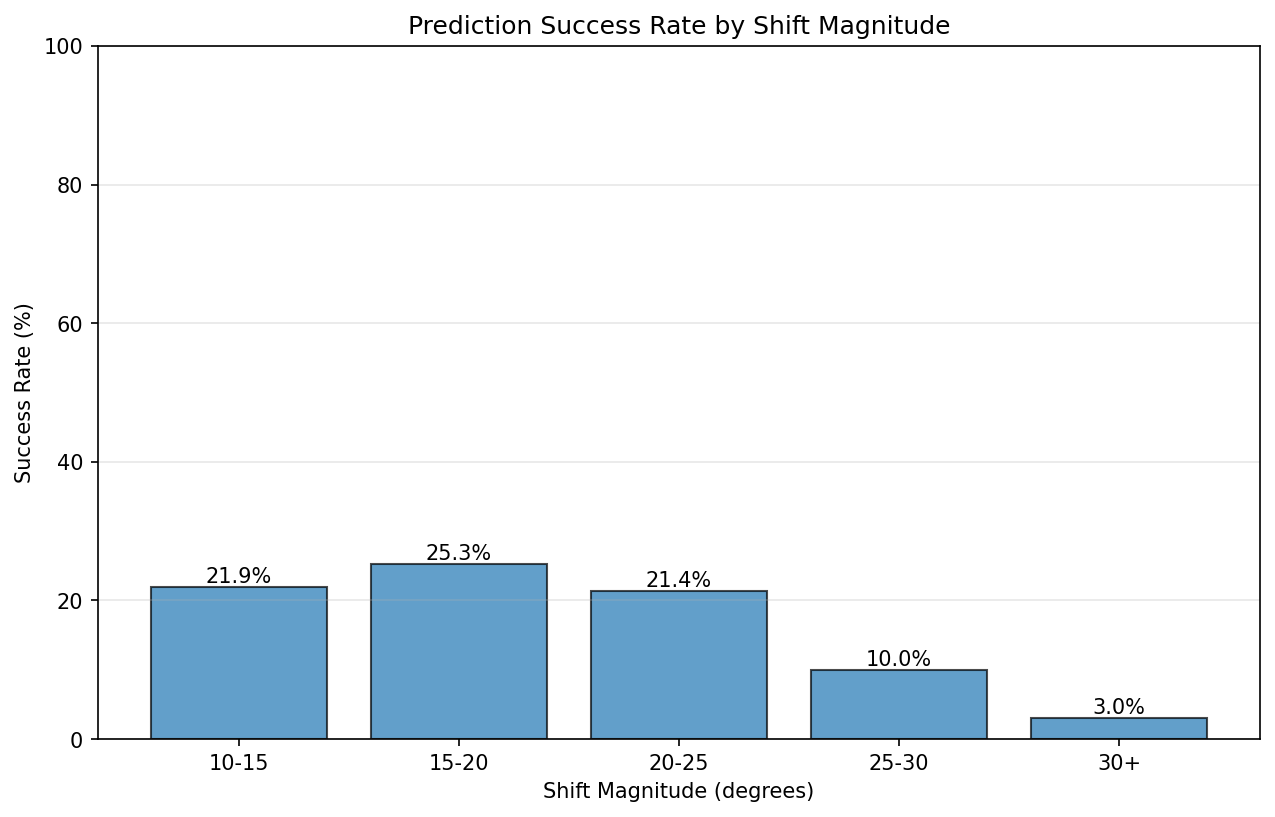


Magnitude vs Lag Time:


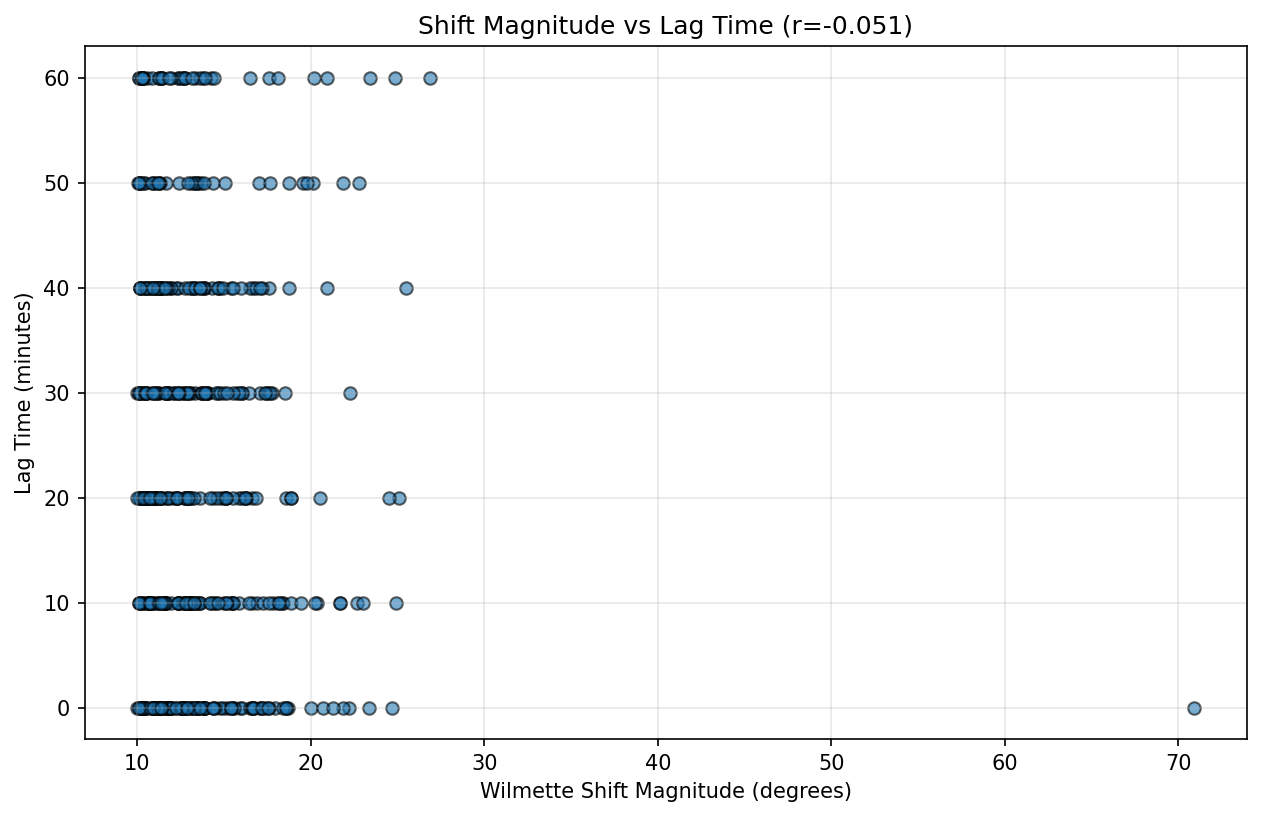


Wilmette vs Chicago Magnitude:


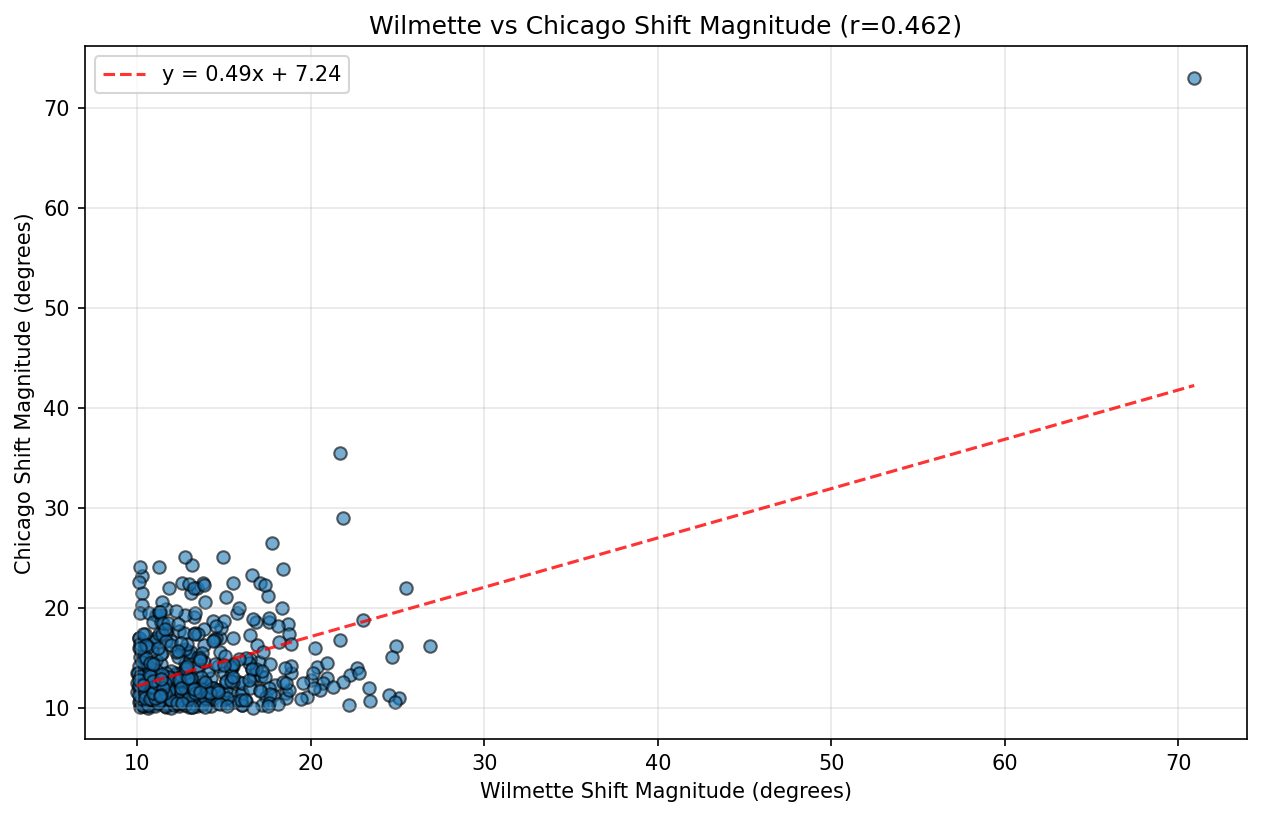

In [11]:
from IPython.display import Image, display

print("Magnitude vs Success Rate:")
display(Image('../results/magnitude_vs_success.png'))

print("\nMagnitude vs Lag Time:")
display(Image('../results/magnitude_vs_lag.png'))

print("\nWilmette vs Chicago Magnitude:")
display(Image('../results/wilmette_vs_chicago_magnitude.png'))

## Section 4: Visual Case Studies and Decision Table

Create the final racing intelligence deliverables: case study plots and a decision table for race-day decisions.

In [12]:
from src.visualizer import (
    select_best_matches,
    select_failure_cases,
    generate_case_study_plot,
    generate_decision_table,
    generate_findings_report
)

# Select case studies
print("=" * 60)
print("Selecting Case Studies")
print("=" * 60)

best_matches = select_best_matches(matched_events, count=3)
failure_cases = select_failure_cases(matched_events, count=3)

print(f"\nBest Matches (shortest lag + strong conditions):")
for i, match in enumerate(best_matches, 1):
    print(f"  {i}. {match.wilmette_shift.timestamp} - Lag: {match.lag_time} min, "
          f"Wind: {match.wilmette_shift.wind_speed:.1f} kt, "
          f"Magnitude: {match.wilmette_shift.magnitude:.1f}°")

print(f"\nFailure Cases (strongest Wilmette shifts with no match):")
for i, failure in enumerate(failure_cases, 1):
    print(f"  {i}. {failure.wilmette_shift.timestamp} - "
          f"Magnitude: {failure.wilmette_shift.magnitude:.1f}°, "
          f"Wind: {failure.wilmette_shift.wind_speed:.1f} kt")

Selecting Case Studies

Best Matches (shortest lag + strong conditions):
  1. 2025-05-20 01:30:00 - Lag: 0 min, Wind: 18.7 kt, Magnitude: 13.2°
  2. 2024-09-01 19:00:00 - Lag: 0 min, Wind: 16.3 kt, Magnitude: 10.8°
  3. 2024-09-01 20:00:00 - Lag: 0 min, Wind: 16.3 kt, Magnitude: 10.1°

Failure Cases (strongest Wilmette shifts with no match):
  1. 2021-08-14 11:10:00 - Magnitude: 58.3°, Wind: 8.4 kt
  2. 2023-05-20 08:00:00 - Magnitude: 51.8°, Wind: 10.7 kt
  3. 2022-07-25 13:10:00 - Magnitude: 45.2°, Wind: 6.2 kt


### Generate Case Study Plots

Create 3-hour time-series overlay plots for best matches and failure cases.

In [13]:
# Generate best match plots
print("\n" + "=" * 60)
print("Generating Case Study Plots")
print("=" * 60)

for i, match in enumerate(best_matches, 1):
    output_path = f'../results/case_studies/best_match_{i:03d}.png'
    generate_case_study_plot(match, wilmette_df, chicago_df, output_path)
    print(f"✓ Generated: case_studies/best_match_{i:03d}.png")

# Generate failure case plots
for i, failure in enumerate(failure_cases, 1):
    output_path = f'../results/case_studies/failure_{i:03d}.png'
    generate_case_study_plot(failure, wilmette_df, chicago_df, output_path)
    print(f"✓ Generated: case_studies/failure_{i:03d}.png")


Generating Case Study Plots
✓ Generated: case_studies/best_match_001.png
✓ Generated: case_studies/best_match_002.png
✓ Generated: case_studies/best_match_003.png
✓ Generated: case_studies/failure_001.png
✓ Generated: case_studies/failure_002.png
✓ Generated: case_studies/failure_003.png


### Decision Table

Wind speed × shift magnitude with success rate and average lag for each cell.

In [14]:
print("\n" + "=" * 60)
print("Decision Table: Wind Speed × Shift Magnitude")
print("=" * 60)
print()

decision_table = generate_decision_table(matched_events)
print(decision_table)


Decision Table: Wind Speed × Shift Magnitude

| Wind Speed (kt) | 10-15 | 15-20 | 20-25 | 25-30 | 30+ |
|---|---|---|---|---|---|
| **5-10** | 21% (25 min) | 23% (19 min) | 25% (22 min) | 6% (40 min) | 5% (0 min) |
| **10-15** | 24% (24 min) | 33% (21 min) | 21% (24 min) | 29% (40 min) | 0% (0 min) |
| **15-20** | 20% (19 min) | 12% (30 min) | 0% (0 min) | 0% (0 min) | 0% (0 min) |
| **20+** | 9% (10 min) | 0% (0 min) | 0% (0 min) | 0% (0 min) | 0% (0 min) |


### Generate Findings Report

Create complete FINDINGS.md with all analysis sections and tactical recommendations.

In [15]:
print("\n" + "=" * 60)
print("Generating Findings Report")
print("=" * 60)

generate_findings_report(
    matched_events=matched_events,
    decision_table_md=decision_table,
    case_study_dir='results/case_studies',
    output_path='../results/FINDINGS.md'
)

print("\n✓ Generated: results/FINDINGS.md")
print("\nReport includes:")
print("  - Headline metrics (success rate, lag times)")
print("  - Decision table (wind speed × magnitude)")
print("  - Case study references (6 plots)")
print("  - Tactical recommendations (when to trust signal)")


Generating Findings Report

✓ Generated: results/FINDINGS.md

Report includes:
  - Headline metrics (success rate, lag times)
  - Decision table (wind speed × magnitude)
  - Case study references (6 plots)
  - Tactical recommendations (when to trust signal)


### Display Case Study Examples

Show a few case study plots inline.


Case Study Visualizations

Best Match Example:


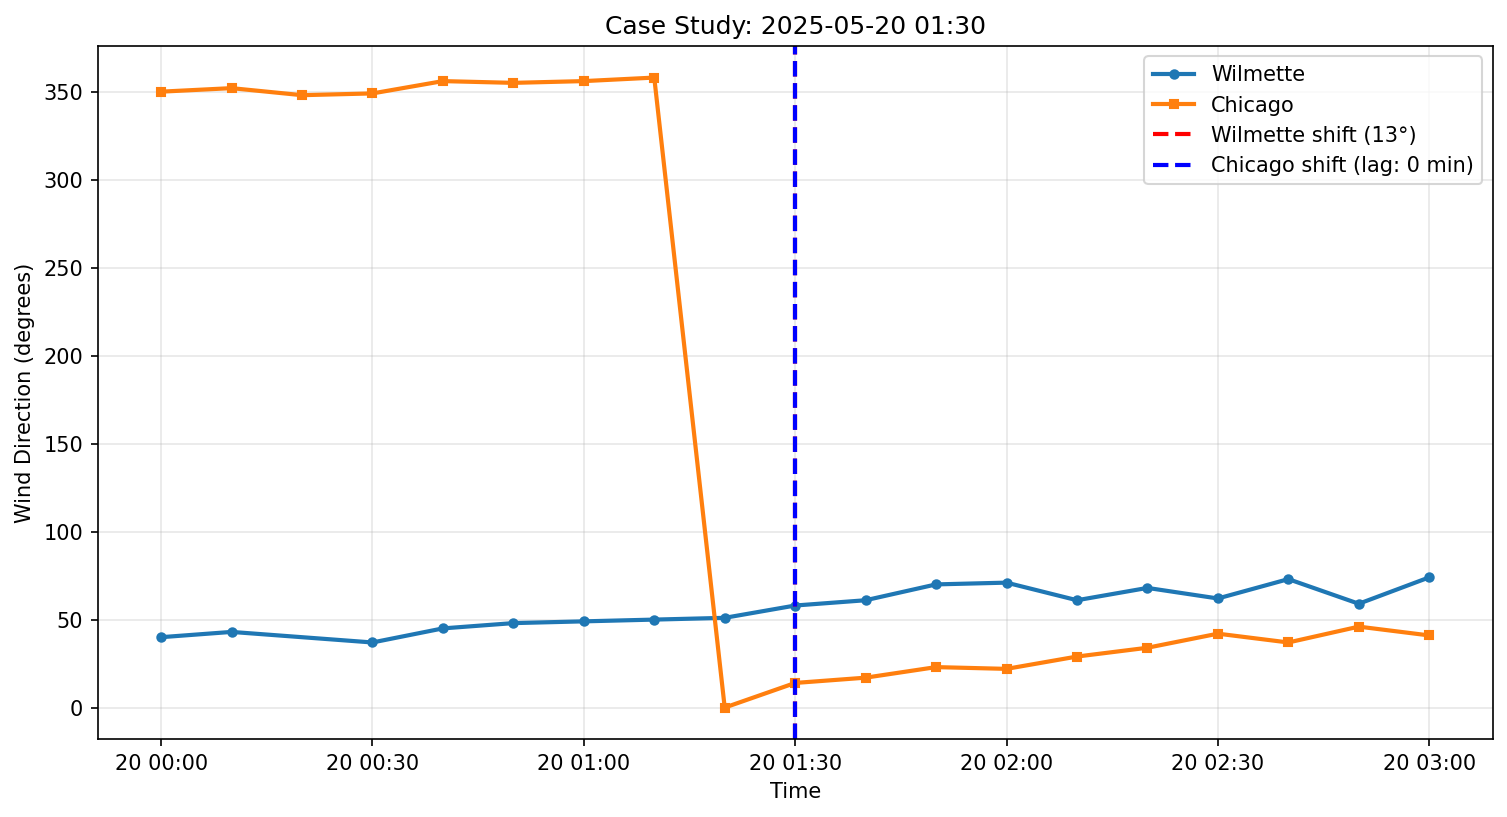


Failure Case Example:


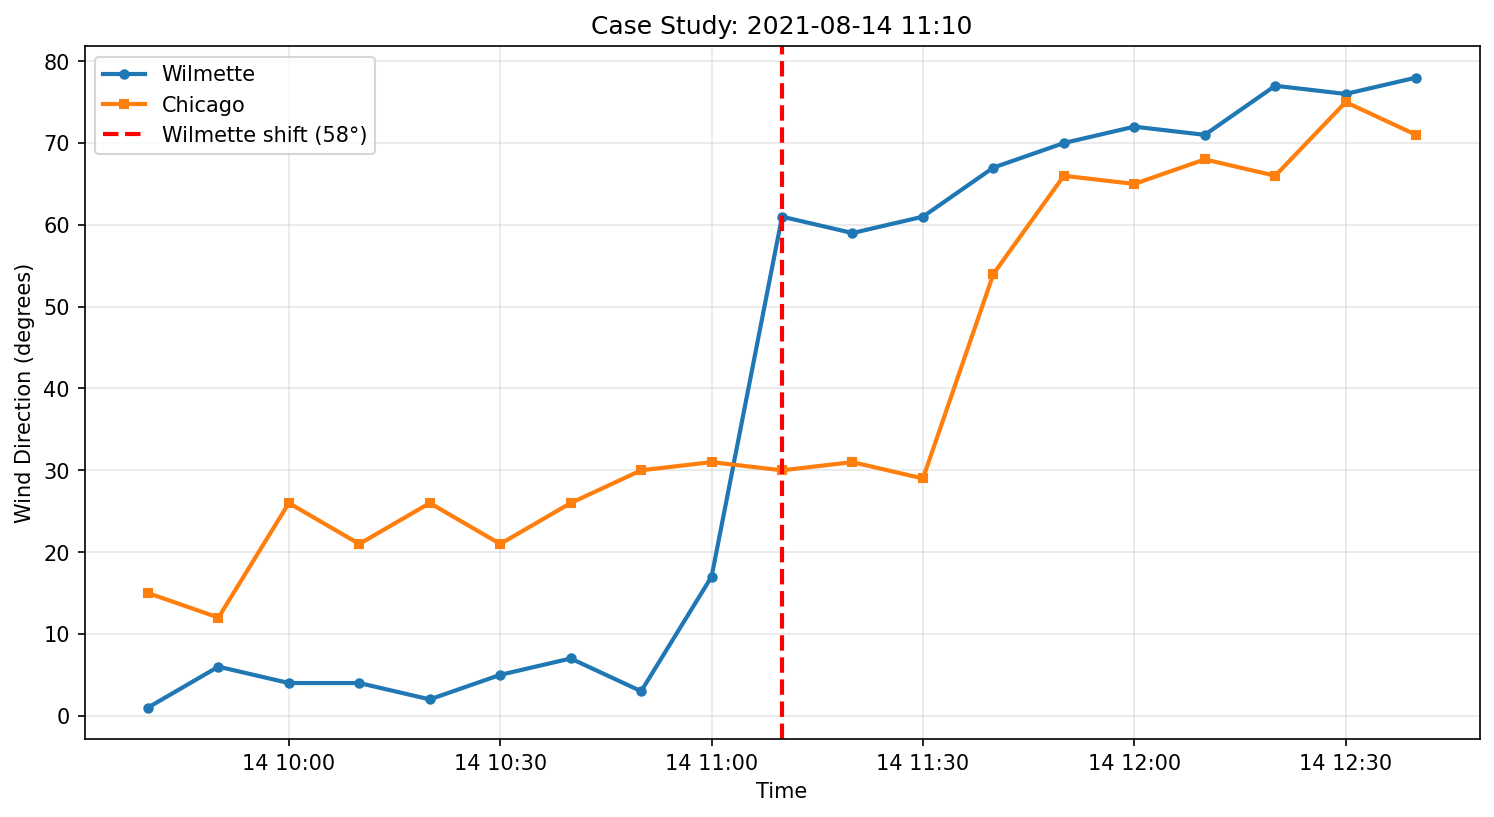

In [16]:
from IPython.display import Image, display

print("\n" + "=" * 60)
print("Case Study Visualizations")
print("=" * 60)

print("\nBest Match Example:")
display(Image('../results/case_studies/best_match_001.png'))

print("\nFailure Case Example:")
display(Image('../results/case_studies/failure_001.png'))